# Bước 1 — Nhập & Làm sạch dữ liệu
**Đề tài:** Mức độ sẵn sàng và nhận thức quản trị AI có trách nhiệm của sinh viên/nhân sự trẻ tại TP.HCM  
**Mô hình:** UTAUT2 mở rộng (EE · PE · SI · FC · RA · ANX → BI)  

---
### Quy trình bước này
1. Cài thư viện
2. Upload & đọc CSV
3. Đổi tên cột ngắn gọn
4. Mã hóa Likert → số (1–5)
5. Phát hiện & loại straight-lining
6. Kiểm tra missing values
7. Xuất file sạch

In [ ]:
# ── Cài thư viện cần thiết ──────────────────────────────────────────
!pip install pyreadstat openpyxl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from google.colab import files

print('Thư viện đã sẵn sàng!')

Thư viện đã sẵn sàng!


---
## 1. Upload & đọc file CSV

In [ ]:
# Upload file CSV từ máy tính
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_csv(filename)
print(f'File: {filename}')
print(f'Số phản hồi: {len(df_raw)}')
print(f'Số cột: {len(df_raw.columns)}')

Saving khao_sat_200_mau_gia_lap.csv to khao_sat_200_mau_gia_lap.csv
File: khao_sat_200_mau_gia_lap.csv
Số phản hồi: 200
Số cột: 44


---
## 2. Đổi tên cột ngắn gọn

In [ ]:
# Lấy tên cột gốc
cols = df_raw.columns.tolist()

# Tên viết tắt tương ứng theo thứ tự cột trong Google Form
# ── Thông tin chung ──────────────────────────────────────────────────
# Col 0: Dấu thời gian
# Col 1: Điểm số (bỏ qua)
# Col 2: Nhóm đối tượng
# Col 3: Ngành học
# Col 4: Mức độ dùng AI
#
# ── Nhóm 1: EE (Effort Expectancy) – cột 5–9 ────────────────────────
# ── Nhóm 2: PE (Performance Expectancy) – cột 10–14 ─────────────────
# ── Nhóm 3: SI (Social Influence) – cột 15–19 ───────────────────────
# ── Nhóm 4: FC (Facilitating Conditions) – cột 20–24 ────────────────
# ── Nhóm 5: RA (Responsible AI Awareness) – cột 25–29 ───────────────
# ── Nhóm 6: ANX (AI Anxiety) – cột 30–34 ───────────────────────────
# ── Nhóm 7: BI (Behavioral Intention) – cột 35–39 ──────────────────
# ── Câu hỏi mở – cột 40–42 ──────────────────────────────────────────

rename_map = {
    cols[0]:  'timestamp',
    cols[1]:  'score',
    cols[2]:  'group',
    cols[3]:  'major',
    cols[4]:  'ai_usage',
    # EE
    cols[5]:  'EE1', cols[6]: 'EE2', cols[7]: 'EE3', cols[8]: 'EE4', cols[9]: 'EE5',
    # PE
    cols[10]: 'PE1', cols[11]: 'PE2', cols[12]: 'PE3', cols[13]: 'PE4', cols[14]: 'PE5',
    # SI
    cols[15]: 'SI1', cols[16]: 'SI2', cols[17]: 'SI3', cols[18]: 'SI4', cols[19]: 'SI5',
    # FC
    cols[20]: 'FC1', cols[21]: 'FC2', cols[22]: 'FC3', cols[23]: 'FC4', cols[24]: 'FC5',
    # RA
    cols[25]: 'RA1', cols[26]: 'RA2', cols[27]: 'RA3', cols[28]: 'RA4', cols[29]: 'RA5',
    # ANX
    cols[30]: 'ANX1', cols[31]: 'ANX2', cols[32]: 'ANX3', cols[33]: 'ANX4', cols[34]: 'ANX5',
    # BI
    cols[35]: 'BI1', cols[36]: 'BI2', cols[37]: 'BI3', cols[38]: 'BI4', cols[39]: 'BI5',
    # Câu hỏi mở
    cols[40]: 'open_q1',
    cols[41]: 'open_q2',
    cols[42]: 'open_q3',
}

df = df_raw.rename(columns=rename_map).copy()
print('Đã đổi tên cột xong!')
print(df[['group','major','ai_usage']].head(3))

Đã đổi tên cột xong!
                                  group                               major  \
0  Sinh viên năm cuối (chưa tốt nghiệp)  Kỹ thuật / CNTT / Khoa học dữ liệu   
1  Sinh viên năm cuối (chưa tốt nghiệp)  Kỹ thuật / CNTT / Khoa học dữ liệu   
2  Sinh viên năm cuối (chưa tốt nghiệp)  Kỹ thuật / CNTT / Khoa học dữ liệu   

                                   ai_usage  
0  Dùng thường xuyên (vài lần/tuần trở lên)  
1  Dùng thường xuyên (vài lần/tuần trở lên)  
2  Dùng thường xuyên (vài lần/tuần trở lên)  


---
## 3. Mã hóa Likert → số (1–5)

In [ ]:
likert_map = {
    'Hoàn toàn không đồng ý': 1,
    'Không đồng ý'           : 2,
    'Trung lập'              : 3,
    'Đồng ý'                 : 4,
    'Hoàn toàn đồng ý'       : 5
}

# Danh sách tất cả biến Likert
likert_cols = (
    [f'EE{i}'  for i in range(1,6)] +
    [f'PE{i}'  for i in range(1,6)] +
    [f'SI{i}'  for i in range(1,6)] +
    [f'FC{i}'  for i in range(1,6)] +
    [f'RA{i}'  for i in range(1,6)] +
    [f'ANX{i}' for i in range(1,6)] +
    [f'BI{i}'  for i in range(1,6)]
)

df[likert_cols] = df[likert_cols].replace(likert_map)

# Kiểm tra còn giá trị text nào chưa map không
unmapped = df[likert_cols].isin(likert_map.values())
print('Kiểm tra giá trị sau mã hóa (phải là 1-5):')
unique_vals = pd.unique(df[likert_cols].values.ravel())
print(sorted([v for v in unique_vals if pd.notna(v)]))
print('\nMẫu 3 dòng đầu:')
df[['EE1','EE2','PE1','BI1','BI5']].head(3)

Kiểm tra giá trị sau mã hóa (phải là 1-5):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Mẫu 3 dòng đầu:


/tmp/ipykernel_1958/3710513414.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[likert_cols] = df[likert_cols].replace(likert_map)


,EE1,EE2,PE1,BI1,BI5
0,3,3,4,4,4
1,4,4,4,5,4
2,3,4,4,4,3


---
## 4. Phát hiện & loại straight-lining

In [ ]:
print('=== KIỂM TRA STRAIGHT-LINING ===')
print('(Người chọn cùng 1 đáp án cho TẤT CẢ 35 câu)\n')

straight_idx = []
for i, row in df[likert_cols].iterrows():
    vals = row.dropna().unique()
    if len(vals) == 1:
        straight_idx.append(i)
        print(f'  Dòng {i+1} | {df.loc[i,"timestamp"]} | toàn {int(vals[0])} → LOẠI')

print(f'\nTổng phát hiện: {len(straight_idx)} dòng')
print(f'N trước khi loại: {len(df)}')

df_clean = df.drop(index=straight_idx).reset_index(drop=True)
print(f'N sau khi loại:  {len(df_clean)}')

=== KIỂM TRA STRAIGHT-LINING ===
(Người chọn cùng 1 đáp án cho TẤT CẢ 35 câu)

  Dòng 5 | 14/08/2026 22:33:21 | toàn 3 → LOẠI
  Dòng 16 | 15/08/2026 8:48:18 | toàn 5 → LOẠI
  Dòng 21 | 16/08/2026 22:55:30 | toàn 4 → LOẠI
  Dòng 31 | 17/08/2026 10:59:25 | toàn 1 → LOẠI
  Dòng 32 | 17/08/2026 11:49:38 | toàn 4 → LOẠI
  Dòng 40 | 17/08/2026 14:40:14 | toàn 5 → LOẠI
  Dòng 50 | 27/08/2026 10:07:32 | toàn 4 → LOẠI

Tổng phát hiện: 7 dòng
N trước khi loại: 200
N sau khi loại:  193


---
## 5. Kiểm tra missing values

In [ ]:
print('=== MISSING VALUES (biến Likert) ===')
missing = df_clean[likert_cols].isnull().sum()
missing_nonzero = missing[missing > 0]

if len(missing_nonzero) == 0:
    print('Không có missing values trong các biến Likert!')
else:
    print(missing_nonzero)
    print('\n→ Các dòng có missing:')
    print(df_clean[df_clean[likert_cols].isnull().any(axis=1)][['timestamp'] + list(missing_nonzero.index)])

print(f'\nN cuối cùng dùng để phân tích: {len(df_clean)}')

=== MISSING VALUES (biến Likert) ===
Không có missing values trong các biến Likert!

N cuối cùng dùng để phân tích: 193


---
## 6. Thống kê mô tả nhân khẩu học

In [ ]:
print('=== NHÓM ĐỐI TƯỢNG ===')
grp = df_clean['group'].value_counts()
for k,v in grp.items():
    print(f'  {k}: {v} ({v/len(df_clean)*100:.1f}%)')

print('\n=== NGÀNH HỌC ===')
maj = df_clean['major'].value_counts()
for k,v in maj.items():
    print(f'  {k}: {v} ({v/len(df_clean)*100:.1f}%)')

print('\n=== MỨC ĐỘ DÙNG AI ===')
usage = df_clean['ai_usage'].value_counts()
for k,v in usage.items():
    print(f'  {k}: {v} ({v/len(df_clean)*100:.1f}%)')

=== NHÓM ĐỐI TƯỢNG ===
  Sinh viên năm cuối (chưa tốt nghiệp): 144 (74.6%)
  Đã tốt nghiệp, đang đi làm dưới 2 năm: 49 (25.4%)

=== NGÀNH HỌC ===
  Kỹ thuật / CNTT / Khoa học dữ liệu: 62 (32.1%)
  Khoa học xã hội / Nhân văn / Ngôn ngữ: 51 (26.4%)
  Kinh tế / Quản trị / Kế toán: 46 (23.8%)
  Ngành khác: ___________________________: 34 (17.6%)

=== MỨC ĐỘ DÙNG AI ===
  Dùng thường xuyên (vài lần/tuần trở lên): 163 (84.5%)
  Đã thử 1–2 lần: 24 (12.4%)
  Chưa bao giờ: 6 (3.1%)


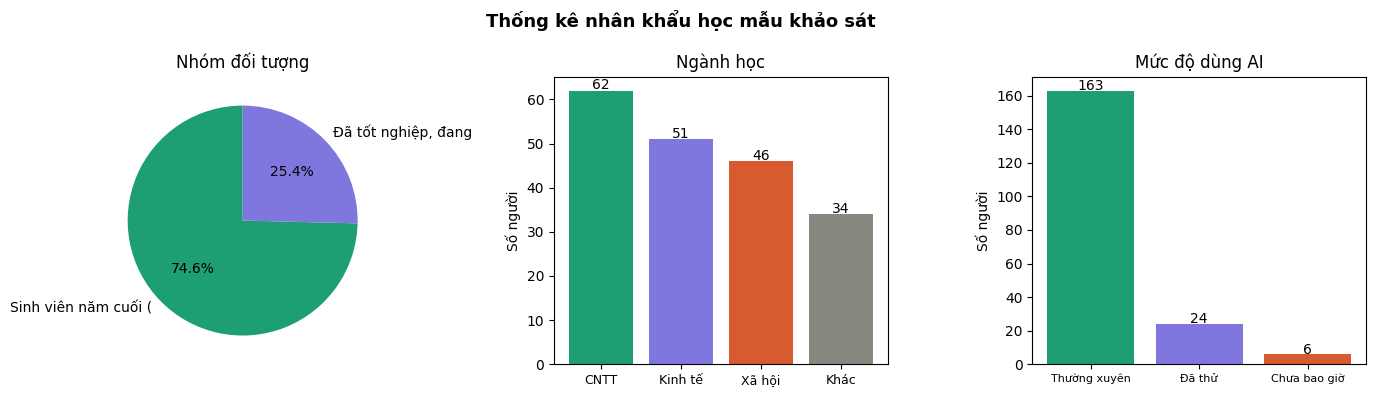

Đã lưu biểu đồ: nhan_khau_hoc.png


In [ ]:
# Biểu đồ nhân khẩu học
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Thống kê nhân khẩu học mẫu khảo sát', fontsize=13, fontweight='bold')

colors = ['#1D9E75','#7F77DD','#D85A30','#888780']

# Nhóm đối tượng
grp_data = df_clean['group'].value_counts()
axes[0].pie(grp_data.values, labels=[l[:20] for l in grp_data.index],
            autopct='%1.1f%%', colors=colors[:len(grp_data)], startangle=90)
axes[0].set_title('Nhóm đối tượng')

# Ngành học
maj_data = df_clean['major'].value_counts()
short_labels = ['CNTT', 'Kinh tế', 'Xã hội', 'Khác']
axes[1].bar(range(len(maj_data)), maj_data.values, color=colors[:len(maj_data)])
axes[1].set_xticks(range(len(maj_data)))
axes[1].set_xticklabels(short_labels[:len(maj_data)], fontsize=9)
axes[1].set_title('Ngành học')
axes[1].set_ylabel('Số người')
for i, v in enumerate(maj_data.values):
    axes[1].text(i, v+0.3, str(v), ha='center', fontsize=10)

# Mức độ dùng AI
usage_data = df_clean['ai_usage'].value_counts()
short_usage = ['Thường xuyên', 'Đã thử', 'Chưa bao giờ']
axes[2].bar(range(len(usage_data)), usage_data.values, color=colors[:len(usage_data)])
axes[2].set_xticks(range(len(usage_data)))
axes[2].set_xticklabels(short_usage[:len(usage_data)], fontsize=8)
axes[2].set_title('Mức độ dùng AI')
axes[2].set_ylabel('Số người')
for i, v in enumerate(usage_data.values):
    axes[2].text(i, v+0.3, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('nhan_khau_hoc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ: nhan_khau_hoc.png')

---
## 7. Thống kê mô tả biến Likert theo nhóm

In [ ]:
groups_map = {
    'EE  (Effort Expectancy)'       : [f'EE{i}'  for i in range(1,6)],
    'PE  (Performance Expectancy)'  : [f'PE{i}'  for i in range(1,6)],
    'SI  (Social Influence)'        : [f'SI{i}'  for i in range(1,6)],
    'FC  (Facilitating Conditions)' : [f'FC{i}'  for i in range(1,6)],
    'RA  (Responsible AI Awareness)': [f'RA{i}'  for i in range(1,6)],
    'ANX (AI Anxiety)'              : [f'ANX{i}' for i in range(1,6)],
    'BI  (Behavioral Intention)'    : [f'BI{i}'  for i in range(1,6)],
}

print(f'{"Nhóm":<38} {"Mean":>6} {"SD":>6} {"Min":>4} {"Max":>4}')
print('-' * 62)
for name, cols_g in groups_map.items():
    vals = df_clean[cols_g].values.flatten().astype(float)
    vals = vals[~np.isnan(vals)]
    print(f'{name:<38} {vals.mean():>6.2f} {vals.std():>6.2f} {vals.min():>4.0f} {vals.max():>4.0f}')

Nhóm                                     Mean     SD  Min  Max
--------------------------------------------------------------
EE  (Effort Expectancy)                  3.58   1.16    1    5
PE  (Performance Expectancy)             3.65   1.20    1    5
SI  (Social Influence)                   3.48   1.06    1    5
FC  (Facilitating Conditions)            3.37   1.17    1    5
RA  (Responsible AI Awareness)           3.96   1.13    1    5
ANX (AI Anxiety)                         3.73   1.05    1    5
BI  (Behavioral Intention)               3.86   1.05    1    5


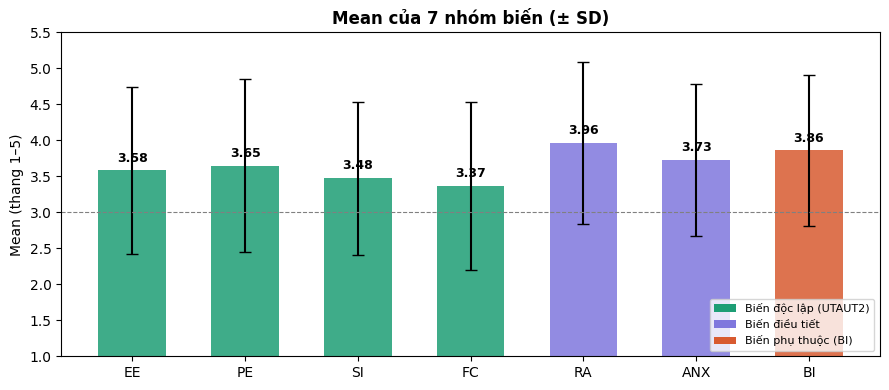

Đã lưu: mean_nhom_bien.png


In [ ]:
# Biểu đồ mean từng nhóm
means = []
sds   = []
labels_short = ['EE','PE','SI','FC','RA','ANX','BI']
for name, cols_g in groups_map.items():
    vals = df_clean[cols_g].values.flatten().astype(float)
    vals = vals[~np.isnan(vals)]
    means.append(vals.mean())
    sds.append(vals.std())

fig, ax = plt.subplots(figsize=(9,4))
bar_colors = ['#1D9E75','#1D9E75','#1D9E75','#1D9E75','#7F77DD','#7F77DD','#D85A30']
bars = ax.bar(labels_short, means, yerr=sds, capsize=4,
              color=bar_colors, alpha=0.85, width=0.6)
ax.axhline(3, color='gray', linestyle='--', linewidth=0.8, label='Điểm trung lập (3.0)')
ax.set_ylim(1, 5.5)
ax.set_ylabel('Mean (thang 1–5)')
ax.set_title('Mean của 7 nhóm biến (± SD)', fontweight='bold')
ax.legend(fontsize=9)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.08,
            f'{m:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chú thích màu
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1D9E75', label='Biến độc lập (UTAUT2)'),
    Patch(facecolor='#7F77DD', label='Biến điều tiết'),
    Patch(facecolor='#D85A30', label='Biến phụ thuộc (BI)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('mean_nhom_bien.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: mean_nhom_bien.png')

---
## 8. Xuất file sạch

In [ ]:
# Xuất CSV sạch (dùng cho các bước tiếp theo)
df_clean.to_csv('data_sach.csv', index=False, encoding='utf-8-sig')
print(f'Đã xuất: data_sach.csv  (N={len(df_clean)})')

# Xuất Excel để xem trực quan
df_clean.to_excel('data_sach.xlsx', index=False)
print(f'Đã xuất: data_sach.xlsx')

# Download về máy
files.download('data_sach.csv')
files.download('data_sach.xlsx')
files.download('nhan_khau_hoc.png')
files.download('mean_nhom_bien.png')

print('\n=== TÓM TẮT ===')
print(f'N ban đầu         : {len(df_raw)}')
print(f'Loại straight-line: {len(straight_idx)}')
print(f'N dùng phân tích  : {len(df_clean)}')
print(f'Số biến Likert    : {len(likert_cols)}')
print('\nBước tiếp theo: chạy Cronbach Alpha (Bước 2)')

Đã xuất: data_sach.csv  (N=193)
Đã xuất: data_sach.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== TÓM TẮT ===
N ban đầu         : 200
Loại straight-line: 7
N dùng phân tích  : 193
Số biến Likert    : 35

Bước tiếp theo: chạy Cronbach Alpha (Bước 2)
